# PCA on Iris for visualization

This notebook uses the Iris dataset to show how PCA can reduce four measured features to a clearer 2D view.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

iris = datasets.load_iris()

features = iris.feature_names
X = iris.data
y = iris.target

#reducing to two dimensions
#features = iris.feature_names[2:]
#X = iris.data[:, 2:]
#y = iris.target
print("Features", features)
print("Target Names", iris.target_names)
print("Shape", X.shape)


Features ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Names ['setosa' 'versicolor' 'virginica']
Shape (150, 4)


**Using Pairwise Scatterplots and Histograms to show 4-dim Data**

This view compares all Iris features pairwise so you can see that some classes already separate well in the raw data.

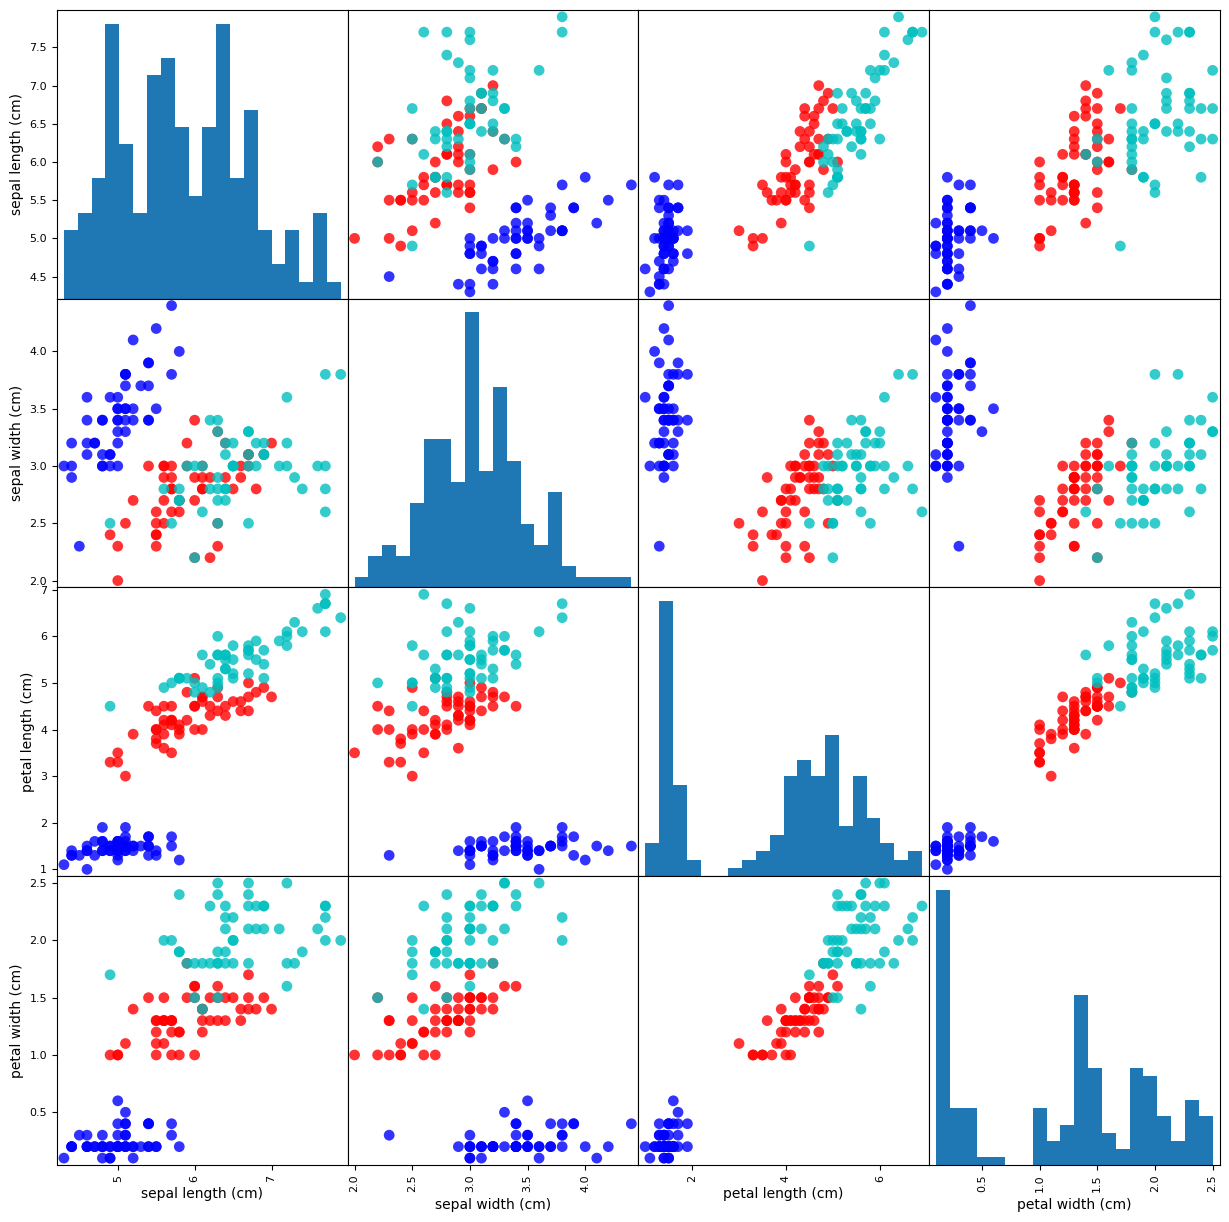

In [2]:
colmap = mpl.colors.ListedColormap(['b', 'g', 'r', 'c'])
join_dataframe = pd.DataFrame(X, columns=features)
allplots = pd.plotting.scatter_matrix(join_dataframe, c=y, 
                           figsize=(15, 15), diagonal='hist',
                           marker='o', hist_kwds={'bins': 20}, s=60,
                           alpha=0.8, cmap=colmap) #mglearn.cm3
plt.show()

In [3]:
from sklearn.decomposition import PCA

np.random.seed(5)
X = iris.data
y = iris.target

pca = PCA(n_components=2) 
pca.fit(X)
print("Shape before:", X.shape)
X = pca.transform(X)
print("Shape after:", X.shape)



Shape before: (150, 4)
Shape after: (150, 2)


['setosa' 'versicolor' 'virginica']


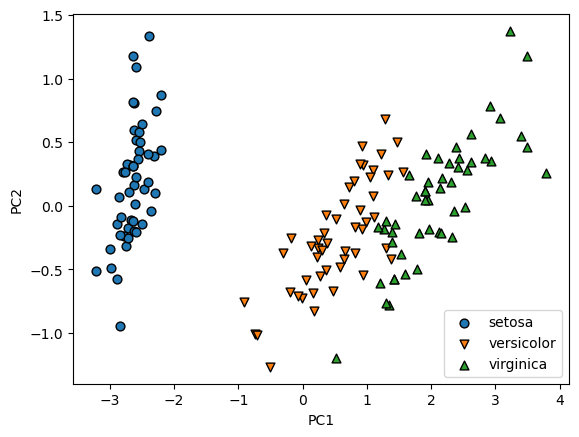

In [4]:
for target_class in np.unique(y):
    plt.scatter(
        X[y == target_class, 0], 
        X[y == target_class, 1], 
        label=iris.target_names[target_class], 
        marker=['o','v','^'][target_class],
        edgecolors= "black",
        s=40)
plt.legend(loc=4)

print(iris.target_names)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Also try: components = 1 